## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')

## Data Understanding

In [8]:
test_df = pd.read_parquet("test-00000-of-00001.parquet")
train_df = pd.read_parquet("train-00000-of-00001.parquet")

In [9]:
train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [10]:
print(train_df.shape)
print(test_df.shape)

print(train_df.columns)
print(test_df.columns)

(120000, 2)
(7600, 2)
Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


## EDA

## Why Concatenate the Datasets?

The original AG News dataset provides separate training and testing datasets. For this project, both datasets are concatenated to create a single unified dataset before performing our own train-test split.

This approach allows us to:

- Perform **EDA on the complete dataset**.
- Have control over the **train-test splitting strategy**.
- Create our own **80:20 stratified train-test split**.
- Follow a consistent end-to-end machine learning workflow.

The test set created after splitting will remain completely unseen during model training and **TF-IDF fitting** to prevent data leakage.

> **Note:** The original AG News train-test split is suitable for benchmark comparisons. However, for this project, we are creating our own split to demonstrate the complete ML pipeline independently.

In [12]:
df = pd.concat([train_df, test_df], ignore_index=True)

print(df.shape)
df.head()

(127600, 2)


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    127600 non-null  object
 1   label   127600 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


In [14]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["label"].value_counts().sort_index()

label
0    31900
1    31900
2    31900
3    31900
Name: count, dtype: int64

In [17]:
for label in sorted(df["label"].unique()):
    print(f"\n{'='*60}")
    print(f"LABEL: {label}")
    print(f"{'='*60}")
    print(df[df["label"] == label]["text"].iloc[0])


LABEL: 0
Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez from\office or give him a new mandate to govern for the next two\years.

LABEL: 1
Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenband and teammate Klete Keller were faster than the teenager in the 200 free preliminaries.

LABEL: 2
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

LABEL: 3
'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the

In [18]:
label_mapping = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

In [19]:
df["category"] = df["label"].map(label_mapping)

In [20]:
df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [22]:
df["text_length"] = df["text"].str.len()

In [23]:
df['text_length'].describe()

count    127600.000000
mean        236.407343
std          66.438756
min         100.000000
25%         196.000000
50%         232.000000
75%         266.000000
max        1012.000000
Name: text_length, dtype: float64

In [24]:
df["word_count"] = df["text"].str.split().str.len()

In [26]:
df['word_count'].describe()

count    127600.000000
mean         37.840000
std          10.087912
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_count, dtype: float64

In [27]:
df.groupby("category")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Business,31900.0,37.543574,8.118145,8.0,32.0,37.0,42.0,134.0
Sci/Tech,31900.0,37.189404,12.446823,8.0,30.0,36.0,42.0,177.0
Sports,31900.0,37.762257,8.861147,8.0,32.0,37.0,42.0,151.0
World,31900.0,38.864765,10.303323,11.0,33.0,39.0,44.0,145.0


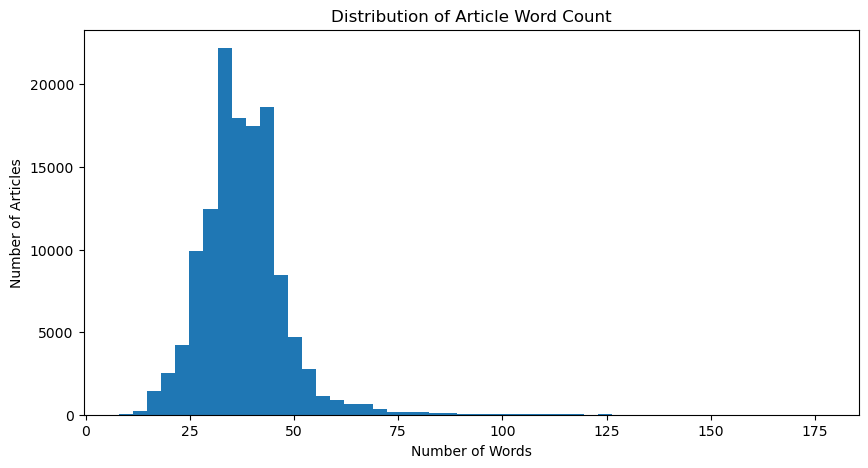

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["word_count"], bins=50)

plt.title("Distribution of Article Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")

plt.show()

<Figure size 1000x500 with 0 Axes>

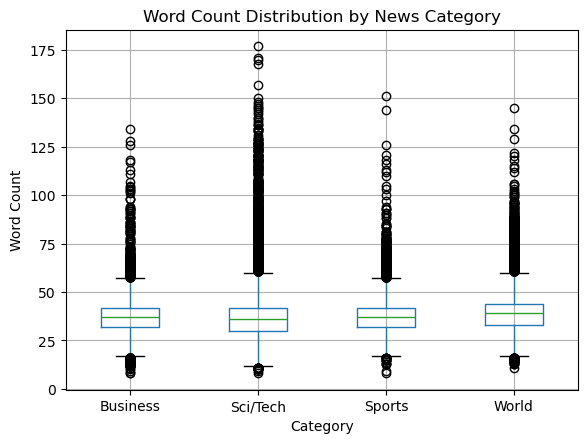

In [29]:
plt.figure(figsize=(10, 5))

df.boxplot(
    column="word_count",
    by="category"
)

plt.title("Word Count Distribution by News Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Word Count")

plt.show()

In [31]:
print("HTML:", df["text"].str.contains(r"<[^>]+>", regex=True).sum())
print("URLs:", df["text"].str.contains(r"http[s]?://|www\.", regex=True).sum())

HTML: 0
URLs: 1946


In [32]:
import string

print(
    "Texts containing punctuation:",
    df["text"].apply(lambda x: any(char in string.punctuation for char in x)).sum()
)

print(
    "Texts containing digits:",
    df["text"].str.contains(r"\d", regex=True).sum()
)

Texts containing punctuation: 127418
Texts containing digits: 74137


In [35]:
df[df["text"].str.contains("#39;", regex=False)]["text"].head(5).tolist()
df["text"].str.contains("#39;", regex=False).sum()

np.int64(31596)

## Text Preprocessing

In [36]:
import re
import html
import string

In [45]:

def preprocess_text(text):
    
    
    text = html.unescape(text)
    
    
    text = re.sub(r"#39;", "'", text)
    
   
    text = re.sub(r"\\[a-zA-Z]", " ", text)
    
    
    text = re.sub(r"\(Reuters\)", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\(AP\)", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\bReuters\s*-\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\bAP\s*-\s*", "", text, flags=re.IGNORECASE)
    
  
    text = text.lower()
    
   
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    
    
    text = text.replace("-", " ")
    
   
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [41]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [42]:
df[["text", "clean_text"]].head(10)

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black short s...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace priv...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook soaring c...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",stocks end up but near year lows stocks ended ...
6,Money Funds Fell in Latest Week (AP) AP - Asse...,money funds fell in latest week assets of the ...
7,Fed minutes show dissent over inflation (USATO...,fed minutes show dissent over inflation usatod...
8,Safety Net (Forbes.com) Forbes.com - After ear...,safety net forbescom forbescom after earning a...
9,Wall St. Bears Claw Back Into the Black NEW Y...,wall st bears claw back into the black new yor...


In [43]:
(df["clean_text"].str.len() == 0).sum()

np.int64(0)

In [44]:
df["clean_word_count"] = df["clean_text"].str.split().str.len()

df["clean_word_count"].describe()

count    127600.000000
mean         37.890862
std          10.083732
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: clean_word_count, dtype: float64

## Train-Test-Split

In [46]:
X=df['clean_text']
Y=df['label']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

## TF-IDF

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [50]:
tfidf = TfidfVectorizer()

In [51]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [52]:
X_test_tfidf = tfidf.transform(X_test)

In [56]:
# parameterized
tf_idf_param=TfidfVectorizer(ngram_range=(1, 2),
min_df=2,
max_df=0.95,
sublinear_tf=True)

In [57]:
X_train_tfidf_param = tf_idf_param.fit_transform(X_train)

In [58]:
X_test_tfidf_param = tf_idf_param.transform(X_test)

## Model Training

In [65]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report

In [61]:
model_nb = MultinomialNB()

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_svm = LinearSVC(
    random_state=42
)

In [62]:
nb_model_param = MultinomialNB()

lr_model_param = LogisticRegression(
    max_iter=1000,
    random_state=42
)

svm_model_param = LinearSVC(
    random_state=42
)

In [71]:
model_nb.fit(X_train_tfidf,Y_train)
Y_pred_nb = model_nb.predict(X_test_tfidf)

acc_nb = accuracy_score(Y_test, Y_pred_nb)
pre_nb = precision_score(Y_test, Y_pred_nb, average="weighted")
rec_nb = recall_score(Y_test, Y_pred_nb, average="weighted")
f1_nb = f1_score(Y_test, Y_pred_nb, average="weighted")

print("Accuracy :", acc_nb)
print("Precision:", pre_nb)
print("Recall   :", rec_nb)
print("F1 Score :", f1_nb)

Accuracy : 0.9063871473354232
Precision: 0.9060872095424735
Recall   : 0.9063871473354232
F1 Score : 0.9061485391460393


In [72]:
model_lr.fit(X_train_tfidf,Y_train)
Y_pred_lr = model_lr.predict(X_test_tfidf)

acc_lr = accuracy_score(Y_test, Y_pred_lr)
pre_lr = precision_score(Y_test, Y_pred_lr, average="weighted")
rec_lr = recall_score(Y_test, Y_pred_lr, average="weighted")
f1_lr = f1_score(Y_test, Y_pred_lr, average="weighted")

print("Accuracy :", acc_lr)
print("Precision:", pre_lr)
print("Recall   :", rec_lr)
print("F1 Score :", f1_lr)

Accuracy : 0.914576802507837
Precision: 0.9143901958224414
Recall   : 0.914576802507837
F1 Score : 0.9143709996061526


In [73]:
model_svm.fit(X_train_tfidf,Y_train)
Y_pred_svm = model_svm.predict(X_test_tfidf)

acc_svm = accuracy_score(Y_test, Y_pred_nb)
pre_svm = precision_score(Y_test, Y_pred_nb, average="weighted")
rec_svm = recall_score(Y_test, Y_pred_nb, average="weighted")
f1_svm = f1_score(Y_test, Y_pred_nb, average="weighted")

print("Accuracy :", acc_svm)
print("Precision:", pre_svm)
print("Recall   :", rec_svm)
print("F1 Score :", f1_svm)

Accuracy : 0.9063871473354232
Precision: 0.9060872095424735
Recall   : 0.9063871473354232
F1 Score : 0.9061485391460393


In [76]:
nb_model_param.fit(X_train_tfidf_param,Y_train)
Y_pred_nb_param = nb_model_param.predict(X_test_tfidf_param)

acc_nb_param = accuracy_score(Y_test, Y_pred_nb_param)
pre_nb_param = precision_score(Y_test, Y_pred_nb_param, average="weighted")
rec_nb_param = recall_score(Y_test, Y_pred_nb_param, average="weighted")
f1_nb_param = f1_score(Y_test, Y_pred_nb_param, average="weighted")

print("Accuracy :", acc_nb_param)
print("Precision:", pre_nb_param)
print("Recall   :", rec_nb_param)
print("F1 Score :", f1_nb_param)


Accuracy : 0.9070532915360502
Precision: 0.9066843797834692
Recall   : 0.9070532915360502
F1 Score : 0.9067488007784392


In [77]:
lr_model_param.fit(X_train_tfidf_param,Y_train)
Y_pred_lr_param = lr_model_param.predict(X_test_tfidf_param)

acc_lr_param = accuracy_score(Y_test, Y_pred_lr_param)
pre_lr_param = precision_score(Y_test, Y_pred_lr_param, average="weighted")
rec_lr_param = recall_score(Y_test, Y_pred_lr_param, average="weighted")
f1_lr_param = f1_score(Y_test, Y_pred_lr_param, average="weighted")

print("Accuracy :", acc_lr_param)
print("Precision:", pre_lr_param)
print("Recall   :", rec_lr_param)
print("F1 Score :", f1_lr_param)


Accuracy : 0.9154388714733542
Precision: 0.9152592502171236
Recall   : 0.9154388714733542
F1 Score : 0.9152230488633352


In [78]:
svm_model_param.fit(X_train_tfidf_param,Y_train)
Y_pred_svm_param = svm_model_param.predict(X_test_tfidf_param)

acc_svm_param = accuracy_score(Y_test, Y_pred_svm_param)
pre_svm_param = precision_score(Y_test, Y_pred_svm_param, average="weighted")
rec_svm_param = recall_score(Y_test, Y_pred_svm_param, average="weighted")
f1_svm_param = f1_score(Y_test, Y_pred_svm_param, average="weighted")

print("Accuracy :", acc_svm_param)
print("Precision:", pre_svm_param)
print("Recall   :", rec_svm_param)
print("F1 Score :", f1_svm_param)


Accuracy : 0.9219043887147336
Precision: 0.9217652948985888
Recall   : 0.9219043887147336
F1 Score : 0.9217473352048565


In [79]:
import plotly.express as px

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes (Param)",
        "Logistic Regression (Param)",
        "Linear SVM (Param)"
    ],
    
    "Accuracy": [
        acc_nb,
        acc_lr,
        acc_svm,
        acc_nb_param,
        acc_lr_param,
        acc_svm_param
    ],
    
    "Precision": [
        pre_nb,
        pre_lr,
        pre_svm,
        pre_nb_param,
        pre_lr_param,
        pre_svm_param
    ],
    
    "Recall": [
        rec_nb,
        rec_lr,
        rec_svm,
        rec_nb_param,
        rec_lr_param,
        rec_svm_param
    ],
    
    "F1 Score": [
        f1_nb,
        f1_lr,
        f1_svm,
        f1_nb_param,
        f1_lr_param,
        f1_svm_param
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.906387,0.906087,0.906387,0.906149
1,Logistic Regression,0.914577,0.914390,0.914577,0.914371
2,Linear SVM,0.906387,0.906087,0.906387,0.906149
3,Naive Bayes (Param),0.907053,0.906684,0.907053,0.906749
4,Logistic Regression (Param),0.915439,0.915259,0.915439,0.915223
5,Linear SVM (Param),0.921904,0.921765,0.921904,0.921747


In [81]:
results_long = results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

results_long

,Model,Metric,Score
0,Naive Bayes,Accuracy,0.906387
1,Logistic Regression,Accuracy,0.914577
2,Linear SVM,Accuracy,0.906387
3,Naive Bayes (Param),Accuracy,0.907053
4,Logistic Regression (Param),Accuracy,0.915439
5,Linear SVM (Param),Accuracy,0.921904
6,Naive Bayes,Precision,0.906087
7,Logistic Regression,Precision,0.914390
8,Linear SVM,Precision,0.906087
9,Naive Bayes (Param),Precision,0.906684


In [84]:
fig = px.bar(
    results_long,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    title="Model Performance Comparison",
    text_auto=".3f"
)

fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Score",
    yaxis_range=[0.85, 1.0],
    legend_title="Metric",
    height=600
)

fig.show()

In [85]:
best_model = results.loc[results["F1 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])

Best Model: Linear SVM (Param)
F1 Score: 0.9217473352048565
